In [1]:
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Clustering
from sklearn.cluster import KMeans

DATA = "data/CrashData.csv"
# Load the dataset
data = pd.read_csv(DATA)

C:\Users\Tao Groves\AppData\Local\Temp\ipykernel_40408\1571869639.py:19: DtypeWarning: Columns (47,49,51,53,63,64) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(DATA)


In [ ]:
# encode categorical values
# Encode categorical values
def split_string(string):
    # If the string is empty or nan, return an empty list
    if string == "" or pd.isnull(string):
        return []
    # Break down each string into a list if there is a semicolon
    if ";" in str(string):
        parts = string.split(";")
        return parts
    else:
        return [string]

def find_id(string):
    string = str(string).strip()
    result = ""
    for char in string:
        if char.isdigit():
            result += char
        elif char == ".":
            return result
        else:
            break
    return None

def clean_values(string):
    individual_strings: list = split_string(string)
    output: list = []
    for string in individual_strings:
        if find_id(string):
            output.append(find_id(string))
        else:
            output.append(string)
    return output

# Apply clean_values to all of the categorical columns
for column in data.columns:
    if data[column].dtype == "object":
        data[column] = data[column].apply(clean_values)

In [ ]:
for column in data.columns:
    if data[column].dtype == "object":
        data[column] = data[column].apply(lambda x: x if type(x) != list else x[0] if len(x) > 0 else None)

data.head()

In [ ]:
# One hot encode
# Identify categorical variables
categorical_vars = data.select_dtypes(include=['object']).columns.tolist()
print("Categorical variables:")
print(categorical_vars)

# Initialize the encoder
encoder = OrdinalEncoder()

# Encode categorical variables
data[categorical_vars] = data[categorical_vars].fillna('Missing')
data[categorical_vars] = encoder.fit_transform(data[categorical_vars])# Encode categorical values

In [ ]:
# Drop rows with missing 'CRASH_SEVERITY'
data = data.dropna(subset=['Crash_Severity'])

# Identify numerical and categorical columns
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

# # Fill missing values
for col in numerical_cols:
    data[col] = data[col].fillna(data[col].mean())
for col in categorical_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

# One-Hot Encode categorical variables
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

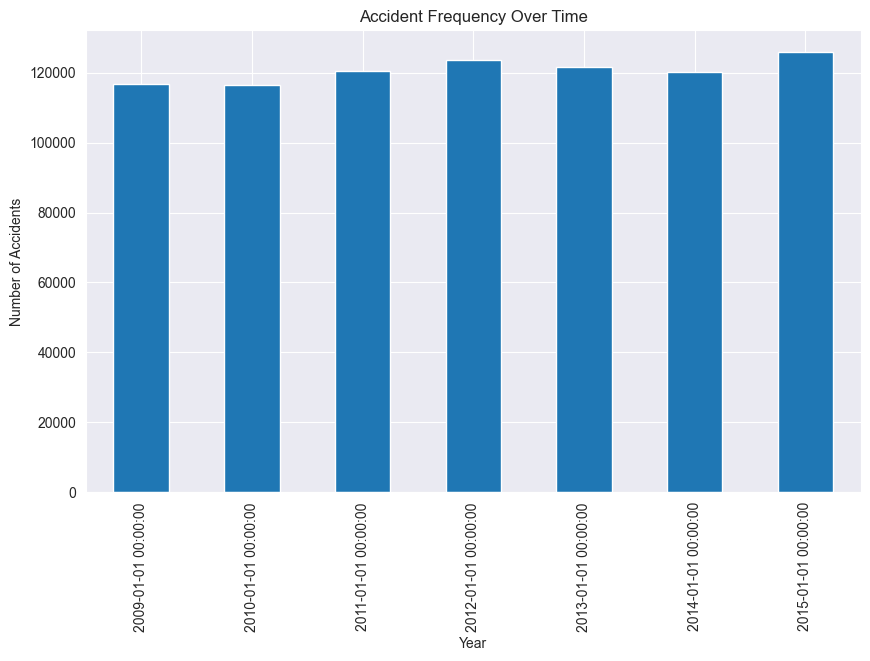

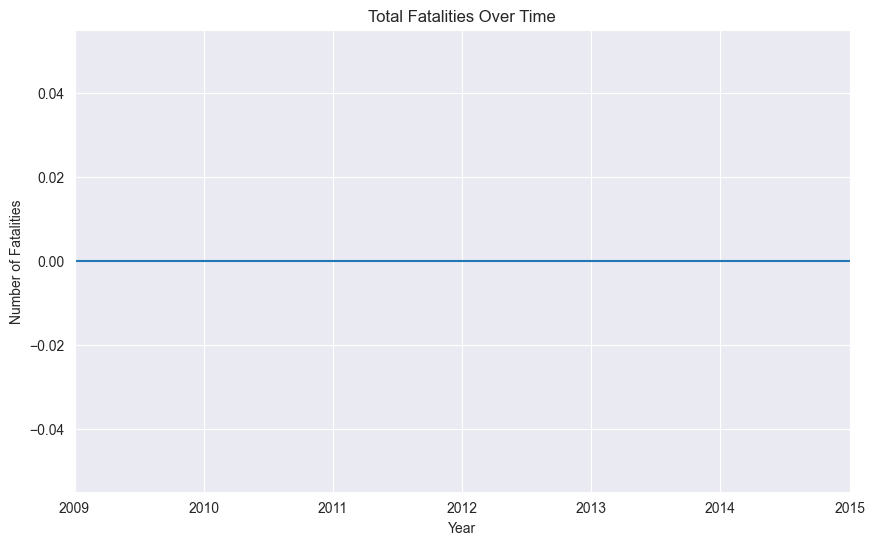

In [3]:
# plot accident frequency, severity, and fatalities over time
data['Crash_Year'] = pd.to_datetime(data['Crash_Year'], format='%Y')

# Plot accident frequency over time
plt.figure(figsize=(10, 6))
data['Crash_Year'].value_counts().sort_index().plot(kind='bar')
plt.title('Accident Frequency Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.show()

# Plot average crash severity over time
# plt.figure(figsize=(10, 6))
# data.groupby('Crash_Year')['Crash_Severity'].mean().plot(kind='line')
# plt.title('Average Crash Severity Over Time')
# plt.xlabel('Year')
# plt.ylabel('Average Crash Severity')
# plt.show()

# Plot total fatalities over time
# Assuming 'Driver_InjuryType' contains information about fatalities
# and that a value of 1 indicates a fatality
plt.figure(figsize=(10, 6))
data['Fatalities'] = data['Driver_InjuryType'].apply(lambda x: 1 if x == 1 else 0)
data.groupby('Crash_Year')['Fatalities'].sum().plot(kind='line')
plt.title('Total Fatalities Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Fatalities')
plt.show()